## MVP ANA - Semantic Frequency Analysis of Brazilian Legal Documents

### Project Overview

This notebook implements a full NLP pipeline that transforms raw PDF legal documents into structured semantic frequency statistics. Starting from scanned or digital court documents, the pipeline extracts sentences, normalises encoding artifacts, removes boilerplate, segments into sentences, normalises citations, and clusters semantically similar sentences using UMAP + HDBSCAN. Case type labels are assigned post-hoc to each cluster using regex applied to the cluster's representative sentence.

### Domain Context: Brazilian Legal Document Analysis

#### Core Domain Definition
Brazilian court documents (petições, acórdãos, sentenças, despachos) address a wide variety of criminal case types. Clustering all sentences together and labelling clusters post-hoc via regex allows pattern discovery across the full corpus, revealing recurring arguments, standard precedents, and emergent legal themes that may not match any predefined case type.

### Problem Definition: Semantic Frequency Analysis Pipeline

#### Problem Statement
Develop a pipeline that ingests Brazilian legal PDFs and outputs frequency statistics of semantically grouped sentences per criminal case type. The statistics surface recurring thematic clusters, enabling researchers and practitioners to identify dominant legal arguments, frequently cited precedents, and standard procedural language at scale.

#### Technical Requirements
- **Problem Type**: Unsupervised clustering with post-hoc case type labeling
- **Input Format**: Brazilian legal PDFs (digital or scanned)
- **Output Format**: Cluster frequency tables, similarity matrices, and static visualizations
- **Difficulty Level**: High — multilingual NLP, OCR, domain-specific abbreviations, sparse legal corpora

#### Data Landscape
The pipeline processes:
- Raw PDF pages (digital text layer or scanned images)
- 768-dim BERT embeddings per sentence
- UMAP 5-dim projection across all sentences
- HDBSCAN cluster assignments and membership probabilities
- Post-hoc case type labels per cluster (regex on representative sentence)

### References

- **Architecture Decision Record**: [semantic_analysis_solution_adr.docx](docs/semantic_analysis_solution_adr.docx) — Documents the pipeline design, technology choices, and rationale for each step;
- **BERTimbau model**: [neuralmind/bert-base-portuguese-cased](https://huggingface.co/neuralmind/bert-base-portuguese-cased) — Portuguese BERT used for sentence embeddings as a substitute for LegalBERT-pt;
- **spaCy pt_core_news_lg**: Portuguese language model for sentence segmentation with legal abbreviation rules;

---

This notebook serves as the primary entry point for the MVP ANA implementation. Each pipeline step is self-contained and its output is checkpointed to disk, allowing individual steps to be re-run without re-executing expensive upstream operations.

### Import Libraries

Installation and import of all required libraries. Warning verbosity is suppressed globally to keep notebook output clean.

In [1]:
%pip install pdfplumber pytesseract Pillow ftfy spacy scikit-learn umap-learn hdbscan transformers torch numpy matplotlib
#!python -m spacy download pt_core_news_lg

import warnings
import logging
import importlib
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add pipeline scripts to Python path
scripts_path = Path("./pipeline/scripts")
if str(scripts_path.resolve()) not in sys.path:
    sys.path.insert(0, str(scripts_path.resolve()))

# Import and reload all pipeline step modules to pick up changes without kernel restart
import pipeline_step
import pipeline_manager
import step_0_pdf_reader
import step_1_encoding_normalizer
import step_2_boilerplate_remover
import step_3_sentence_segmenter
import step_4_citation_normalizer
import step_5_embedding_generator
import step_6_umap_reducer
import step_7_hdbscan_clusterer
import step_8_statistics_generator
import step_9_visualizer
import step_10_xml_exporter

importlib.reload(pipeline_step)
importlib.reload(pipeline_manager)
importlib.reload(step_0_pdf_reader)
importlib.reload(step_1_encoding_normalizer)
importlib.reload(step_2_boilerplate_remover)
importlib.reload(step_3_sentence_segmenter)
importlib.reload(step_4_citation_normalizer)
importlib.reload(step_5_embedding_generator)
importlib.reload(step_6_umap_reducer)
importlib.reload(step_7_hdbscan_clusterer)
importlib.reload(step_8_statistics_generator)
importlib.reload(step_9_visualizer)
importlib.reload(step_10_xml_exporter)

from pipeline_step import PipelineStep
from pipeline_manager import PipelineManager
from step_0_pdf_reader import PdfReader, PdfReaderInput
from step_1_encoding_normalizer import EncodingNormalizer
from step_2_boilerplate_remover import BoilerplateRemover
from step_3_sentence_segmenter import SentenceSegmenter
from step_4_citation_normalizer import CitationNormalizer
from step_5_embedding_generator import EmbeddingGenerator
from step_6_umap_reducer import UmapReducer
from step_7_hdbscan_clusterer import HdbscanClusterer
from step_8_statistics_generator import StatisticsGenerator
from step_9_visualizer import Visualizer
from step_10_xml_exporter import XmlExporter

# Suppress warnings and verbose loggers
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(name)s - %(levelname)s - %(message)s")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("umap").setLevel(logging.ERROR)
logging.getLogger("numba").setLevel(logging.ERROR)

Note: you may need to restart the kernel to use updated packages.


2026-03-17 07:24:18.657488: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Pipeline Configuration

All tunable parameters are defined here as a single source of truth. `random_seed` propagates to every step that requires stochastic reproducibility (UMAP, any future fine-tuned model).

In [2]:
# Global parameters
random_seed = 42  # PARAMETER: single source of randomness for all components

# Step 0
pdf_path = Path("./datasets/Súmulas - STJ.pdf")  # PARAMETER: path to the input PDF

ocr_fallback = True  # PARAMETER: attempt OCR for scanned pages
min_page_text = 50  # PARAMETER: minimum characters per page before OCR fallback

# Step 2
tfidf_threshold = 0.92  # PARAMETER: cosine similarity threshold for boilerplate detection

# Step 3
min_sentence_tokens = 5  # PARAMETER: minimum tokens for a sentence to be retained
max_length_sentence_segmenter = 10000000  # PARAMETER: max character length for spaCy pipeline

# Step 5
embedding_batch_size = 16  # PARAMETER: sentences per inference batch
max_tokens = 512  # PARAMETER: BERT context window
overlap_tokens = 64  # PARAMETER: sliding window overlap

# Step 6
umap_components = 5  # PARAMETER: UMAP output dimensions
umap_neighbors = 15  # PARAMETER: UMAP neighborhood size

# Step 7
hdbscan_min_cluster = 5  # PARAMETER: HDBSCAN minimum cluster size
hdbscan_min_samples = 3  # PARAMETER: HDBSCAN minimum samples

# Step 8
similarity_threshold = 0.5  # PARAMETER: minimum cosine similarity to assign a named case type

# Checkpoint directory
checkpoint_dir = Path("./pipeline/checkpoints")

print(f"Random seed: {random_seed}")
print(f"Input PDF: {pdf_path}")
print(f"Checkpoint dir: {checkpoint_dir}")

Random seed: 42
Input PDF: datasets/Súmulas - STJ.pdf
Checkpoint dir: pipeline/checkpoints


### Build Pipeline

Instantiate all step processors and register them with the PipelineManager. The manager will execute each step in order, saving outputs to disk so that expensive steps can be skipped on subsequent runs.

In [3]:
steps = [
    PdfReader(min_text_length=min_page_text),
    EncodingNormalizer(),
    BoilerplateRemover(tfidf_threshold=tfidf_threshold),
    SentenceSegmenter(min_tokens=min_sentence_tokens, max_length=max_length_sentence_segmenter),
    CitationNormalizer(),
    EmbeddingGenerator(
        max_tokens=max_tokens,
        overlap_tokens=overlap_tokens,
        batch_size=embedding_batch_size,
    ),
    UmapReducer(
        n_components=umap_components,
        n_neighbors=umap_neighbors,
        random_state=random_seed,
    ),
    HdbscanClusterer(
        min_cluster_size=hdbscan_min_cluster,
        min_samples=hdbscan_min_samples,
    ),
    StatisticsGenerator(similarity_threshold=similarity_threshold),
]

manager = PipelineManager(checkpoint_dir=checkpoint_dir, steps=steps)

status = manager.checkpoint_status()
print("Checkpoint status:")
for step_num, exists in status.items():
    print(f"  Step {step_num:2d}: {'cached' if exists else 'pending'}")

httpx - INFO - HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/neuralmind/bert-base-portuguese-cased/94d69c95f98f7d5b2a8700c420230ae10def0baa/config.json "HTTP/1.1 200 OK"
httpx - INFO - HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/neuralmind/bert-base-portuguese-cased/94d69c95f98f7d5b2a8700c420230ae10def0baa/tokenizer_config.json "HTTP/1.1 200 OK"
httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased/tree/ma

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased/commits/refs%2Fpr%2F5 "HTTP/1.1 200 OK"
httpx - INFO - HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/refs%2Fpr%2F5/model.safetensors.index.json "HTTP/1.1 404 Not Found"
httpx - INFO - HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/refs%2Fpr%2F5/model.safetensors "HTTP/1.1 302 Found"


Checkpoint status:
  Step  0: cached
  Step  1: cached
  Step  2: cached
  Step  3: cached
  Step  4: cached
  Step  5: cached
  Step  6: cached
  Step  7: cached
  Step  8: pending


**Step 0. Read Text from PDF**

pdfplumber extracts the digital text layer directly from the PDF. When a page contains fewer than `min_page_text` characters (indicating a scanned image page), Tesseract OCR is invoked on a 300 DPI rasterisation. This dual approach handles mixed-mode documents common in Brazilian court archives.

In [4]:
pdf_input = PdfReaderInput(
    pdf_path=pdf_path,
    ocr_fallback=ocr_fallback,
    min_text_length=min_page_text,
)
step0_output = manager.run_step(0, pdf_input)
print(f"Pages: {step0_output.page_count}")
print(f"OCR pages: {step0_output.ocr_pages}")
print(f"Text length: {len(step0_output.raw_text):,} characters")
print(f"Preview: {step0_output.raw_text[:300]!r}")

pipeline.manager - INFO - Step 0 loaded from checkpoint


Pages: 2642
OCR pages: []
Text length: 5,391,932 characters
Preview: 'SUMSÁRIO úmulas Organizadas por\nRamo do Direito\nSUMÁRIO\nDIREITO ADMINISTRATIVO - ÁGUA E ESGOTO 30\nSúmula 407 30\nSúmula 412 33\nDIREITO ADMINISTRATIVO - ANISTIA POLÍTICA 35\nSúmula 624 35\nSúmula 647 38\nDIREITO ADMINISTRATIVO - ATIVIDADE FARMACÊUTICA 43\nSúmula 120 43\nSúmula 275 46\nSúmula 413 50\nSúmula 5'


**Step 1. Encoding Normalization**

ftfy repairs mojibake and other encoding artifacts produced by legacy PDF generators (common in Brazilian public sector documents). NFC normalization unifies code-point representations so that subsequent regex and tokenisation steps behave deterministically. All replacements are logged for audit purposes.

In [5]:
step1_output = manager.run_step(1, step0_output)
print(f"Replacements applied: {len(step1_output.replacements)}")
if step1_output.replacements:
    print("Sample replacements:")
    for orig, fixed in step1_output.replacements[:5]:
        print(f"  {orig!r} → {fixed!r}")
print(f"Clean text length: {len(step1_output.clean_text):,} characters")

pipeline.manager - INFO - Step 1 loaded from checkpoint


Replacements applied: 0
Clean text length: 5,391,932 characters


**Step 2. Boilerplate Removal**

Legal documents contain recurring non-informative headers, footers, page numbers, and standard certification phrases. Regex patterns handle deterministic patterns. TF-IDF cosine similarity detects near-duplicate paragraphs that regex alone would miss (e.g., repeated court signatures). Content is replaced with `<BOILERPLATE>` rather than deleted to preserve positional context for downstream steps.

In [6]:
step2_output = manager.run_step(2, step1_output)
print(f"Segments replaced: {step2_output.removed_count}")
print(f"TF-IDF threshold used: {step2_output.tfidf_threshold}")
print(f"Filtered text length: {len(step2_output.filtered_text):,} characters")

pipeline.manager - INFO - Step 2 loaded from checkpoint


Segments replaced: 180
TF-IDF threshold used: 0.92
Filtered text length: 5,355,562 characters


**Step 3. Sentence Segmentation**

spaCy pt_core_news_lg provides a state-of-the-art Portuguese dependency parser that drives sentence boundary detection. A custom `legal_sentence_fixer` component prevents false splits after legal abbreviations (e.g., `art.`, `inc.`, `fls.`) which are extremely common in Brazilian legal texts. Sentences shorter than `min_sentence_tokens` are discarded as noise fragments.

In [7]:
step3_output = manager.run_step(3, step2_output)
print(f"Sentences extracted: {step3_output.sentence_count:,}")
print("\nSample sentences:")
for i, sent in enumerate(step3_output.sentences[:3]):
    print(f"  [{i+1}] {sent[:120]!r}")

pipeline.manager - INFO - Step 3 loaded from checkpoint


Sentences extracted: 52,060

Sample sentences:
  [1] 'Organizadas por\nRamo do Direito'
  [2] 'SUMÁRIO\nDIREITO ADMINISTRATIVO - ÁGUA'
  [3] 'E ESGOTO 30\nSúmula 407 30'


**Step 4. Citation Normalization**

Legal citations (article references, process numbers, case references, súmula numbers) are idiosyncratic strings that would fragment embedding space without normalization. Each citation type is replaced by a typed token (`<ART_REF>`, `<PROC_NUM>`, `<CASE_REF>`, `<SUMULA_REF>`), enabling BERT to focus on rhetorical context. Original citations are stored in `citation_metadata` for reconstruction.

In [8]:
step4_output = manager.run_step(4, step3_output)
total_citations = sum(len(m) for m in step4_output.citation_metadata)
print(f"Sentences processed: {len(step4_output.sentences):,}")
print(f"Total citations normalized: {total_citations:,}")
print("\nSample normalized sentences:")
for i, (sent, meta) in enumerate(zip(step4_output.sentences[:3], step4_output.citation_metadata[:3])):
    print(f"  [{i+1}] {sent[:120]!r}")
    if meta:
        print(f"       Citations: {meta}")

pipeline.manager - INFO - Step 4 loaded from checkpoint


Sentences processed: 52,060
Total citations normalized: 10,420

Sample normalized sentences:
  [1] 'Organizadas por\nRamo do Direito'
  [2] 'SUMÁRIO\nDIREITO ADMINISTRATIVO - ÁGUA'
  [3] 'E ESGOTO 30\nSúmula 407 30'


**Step 5. Embedding with BERTimbau** [STEP CAN BE SKIPPED - re-runs use checkpoint]

BERTimbau (`neuralmind/bert-base-portuguese-cased`) is used as a practical substitute for LegalBERT-pt, which lacks a publicly available checkpoint. Mean pooling over all non-padding token hidden states produces a single 768-dim vector per sentence. Sentences exceeding 512 tokens are processed with a sliding window of `overlap_tokens` to prevent context loss at boundaries. This step now receives `CitationOutput` directly from Step 4.

In [9]:
step5_output = manager.run_step(5, step4_output)
print(f"Model: {step5_output.model_name}")
print(f"Embedding dimension: {step5_output.embedding_dim}")
print(f"Sentences embedded: {len(step5_output.embedded_sentences):,}")
sample_emb = step5_output.embedded_sentences[0].embedding
print(f"Sample vector norm: {float(np.linalg.norm(sample_emb)):.4f}")

pipeline.manager - INFO - Step 5 loaded from checkpoint


Model: neuralmind/bert-base-portuguese-cased
Embedding dimension: 768
Sentences embedded: 52,060
Sample vector norm: 8.1082


**Step 6. UMAP Dimensionality Reduction**

UMAP projects all 768-dim embeddings to 5 dimensions in a single global projection. A unified manifold preserves cross-corpus topology, allowing HDBSCAN to discover density-based clusters that span the entire sentence space without prior case type partitioning. Cosine metric is appropriate for BERT embeddings because their direction carries more semantic information than their magnitude. Fixed `random_state` ensures reproducible projections.

In [10]:
step6_output = manager.run_step(6, step5_output)
print(f"UMAP components: {step6_output.n_components}")
print(f"Metric: {step6_output.metric}")
print(f"Sentences reduced: {len(step6_output.reduced_sentences):,}")
sample_vec = step6_output.reduced_sentences[0].reduced_vector
print(f"Sample reduced vector: {sample_vec}")

pipeline.manager - INFO - Step 6 loaded from checkpoint


UMAP components: 5
Metric: cosine
Sentences reduced: 52,060
Sample reduced vector: [16.87336   10.701755  12.576182   3.8035014 12.820311 ]


**Step 7. HDBSCAN Clustering**

HDBSCAN is applied to all sentences in a single global run on the UMAP-reduced vectors. It does not require specifying the number of clusters and naturally handles noise points (sentences that do not belong to any dense group). Clustering across the full corpus allows emergent thematic patterns to surface without constraint by predefined case type labels. Sentences labeled as noise (cluster_id = -1) are excluded from statistics but are preserved in the output. Case type assignment happens in Step 8 post-hoc.

In [11]:
step7_output = manager.run_step(7, step6_output)
print(f"Total clusters found: {step7_output.total_clusters}")
print(f"Total noise sentences: {step7_output.noise_count:,}")

manager._steps[9] = Visualizer(
    clustering_output=step7_output,
    output_dir=Path("./pipeline/figures"),
)
manager._steps[10] = XmlExporter(
    clustering_output=step7_output,
    results_dir=Path("./pipeline/results"),
)

pipeline.manager - INFO - Step 7 loaded from checkpoint


Total clusters found: 2441
Total noise sentences: 16,838


**Step 8. Generate Statistics**

For each cluster, the statistics step computes: sentence frequency, the representative sentence (highest cosine similarity to the centroid), and mean intra-cluster cosine similarity. Case type labels are assigned post-hoc by comparing the cluster centroid to pre-computed BERTimbau seed embedding vectors for each case type using cosine similarity. The seed embeddings are the mean of three representative sentences per case type encoded by `neuralmind/bert-base-portuguese-cased`. If the highest similarity falls below `similarity_threshold`, the cluster is labeled `Unknown`. The key output is `case_type_frequency`: total sentence count per case type, counting all semantically similar sentences that cluster together. Cross-cluster similarity between centroids reveals thematic overlap across the document.

In [12]:
step8_output = manager.run_step(8, step7_output)
print(f"Total clusters analysed: {step8_output.total_clusters}")
print("\nCase type frequency (post-hoc):")
for case_type, count in sorted(step8_output.case_type_frequency.items(), key=lambda x: -x[1]):
    bar = "#" * (count // max(1, max(step8_output.case_type_frequency.values()) // 20))
    print(f"  {case_type:<22} {count:5d}  {bar}")
print("\nTop 5 clusters by frequency:")
top5 = sorted(step8_output.cluster_stats, key=lambda s: s.frequency, reverse=True)[:5]
for stats in top5:
    print(f"  [cluster-{stats.cluster_id} / {stats.case_type}] freq={stats.frequency} intra_sim={stats.intra_similarity:.3f}")
    print(f"    Representative:     {stats.representative_sentence[:100]!r}")
    print(f"    Non-representative: {stats.non_representative_sentence[:100]!r}")

pipeline.step_8 - INFO - Step 8 [Statistics Generator] started
pipeline.step_8 - INFO - Step 8 [Statistics Generator] completed in 8.81s
pipeline.manager - INFO - Checkpoint saved: pipeline/checkpoints/step_08.pkl


Total clusters analysed: 2441

Case type frequency (post-hoc):
  EstelionatoFraude      18888  ####################
  Unknown                 7852  ########
  ViolenciaDomestica      5675  ######
  CrimesFinanceiros       2060  ##
  AcidenteTransito         564  
  LesaoCorporal             53  
  TraficoDrogas             39  
  FurtoCelular              33  
  HomicidioDoloso           26  
  CasaRoubada               16  
  AssaltoArmado             16  

Top 5 clusters by frequency:
  [cluster-680 / Unknown] freq=295 intra_sim=0.981
    Representative:     'RSSTJ VOL.:00013 PG:00186\nRSTJ'
    Non-representative: 'JBCC VOL.:00158 PG:00242\nJTS'
  [cluster-1405 / EstelionatoFraude] freq=272 intra_sim=0.919
    Representative:     'Ministro HUMBERTO GOMES DE BARROS, TERCEIRA TURMA, julgado em 25/09/2007, DJ\n15/10/2007, p. 256)\n"[.'
    Non-representative: 'Portanto, CONHEÇO do RECURSO ESPECIAL interposto pelo ESTADO DO PARANÁ e CONHEÇO\nPARCIALMENTE do REC'
  [cluster-797 / Violenc

**Step 9. Visualization**

Three complementary static plots are produced:
1. **UMAP scatter** — spatial distribution of sentences coloured by case type reveals inter-group separation and intra-group density
2. **Frequency bar chart** — sentence count per cluster sorted descending, identifying the most recurring thematic groups within each case type
3. **Case type distribution heatmap** — normalized case type proportions across clusters, showing whether clusters are case-type-pure or mixed

All plots are saved to `./pipeline/figures/` for inclusion in reports.

pipeline.step_9 - INFO - Step 9 [Visualizer] started
pipeline.step_9 - INFO - Step 9 [Visualizer] completed in 9.79s
pipeline.manager - INFO - Checkpoint saved: pipeline/checkpoints/step_09.pkl


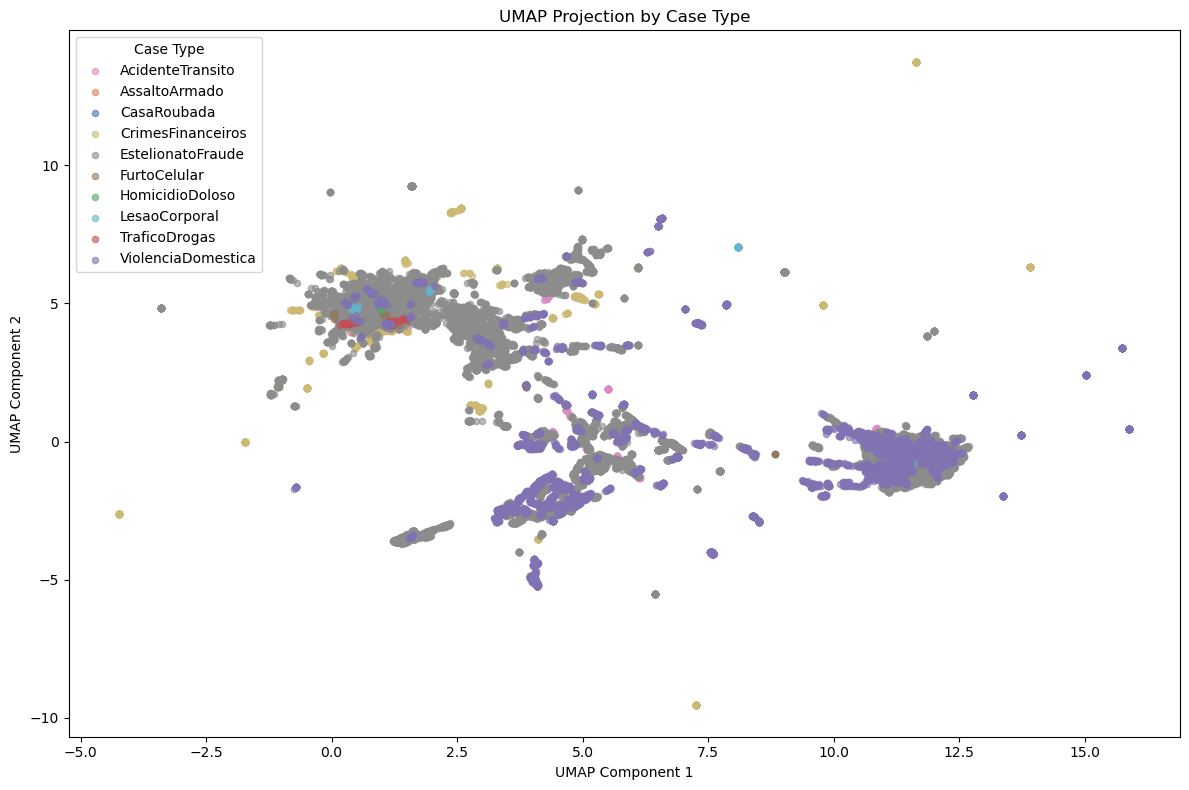

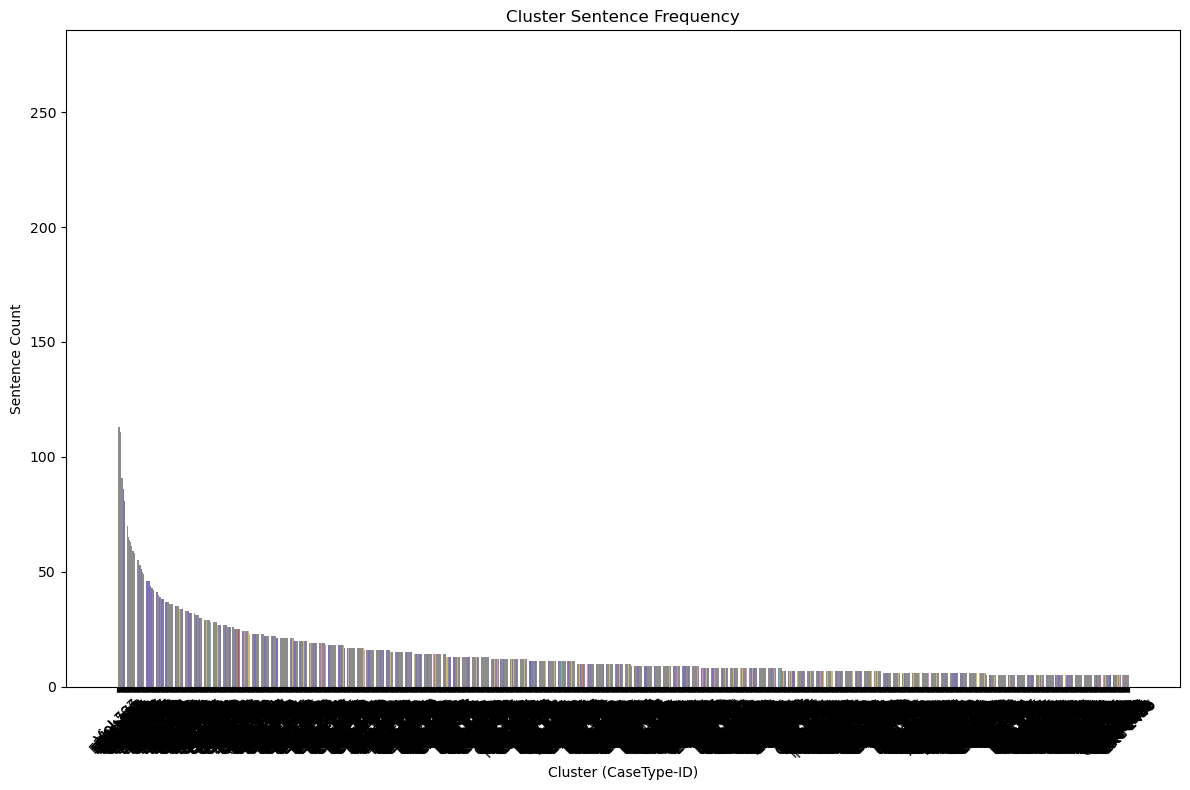

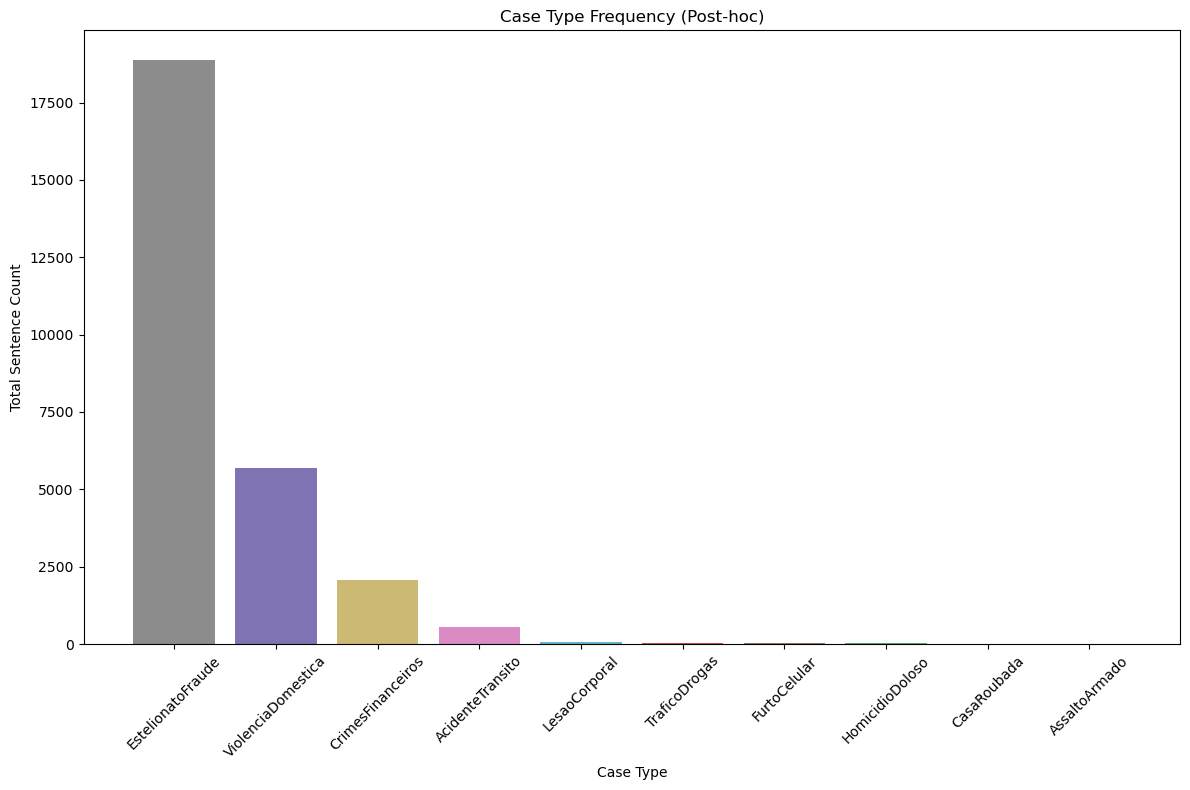


Figures saved to:
  pipeline/figures/umap_scatter.png
  pipeline/figures/frequency_bar.png
  pipeline/figures/case_type_frequency.png


In [13]:
step9_output = manager.run_step(9, step8_output)
for fig in step9_output.figures:
    plt.show()
print("\nFigures saved to:")
for path in step9_output.saved_paths:
    print(f"  {path}")

**Step 10. XML Export**

Each non-Unknown case type cluster group is exported to a dedicated XML file under `pipeline/results/`. Sentences are sourced directly from the HDBSCAN output, carrying `cluster_id` and `membership_probability`. Sorted by cluster then confidence descending.

In [14]:
step10_output = manager.run_step(10, step8_output)
print(f"XML files exported to: {step10_output.results_dir}")
for case_type, count in sorted(step10_output.sentence_counts.items(), key=lambda x: -x[1]):
    print(f"  {case_type:<22} {count:5d} sentences")

pipeline.step_10 - INFO - Step 10 [XML Exporter] started
pipeline.step_10 - INFO - Step 10 [XML Exporter] completed in 0.64s
pipeline.manager - INFO - Checkpoint saved: pipeline/checkpoints/step_10.pkl


XML files exported to: pipeline/results
  EstelionatoFraude      18888 sentences
  ViolenciaDomestica      5675 sentences
  CrimesFinanceiros       2060 sentences
  AcidenteTransito         564 sentences
  LesaoCorporal             53 sentences
  TraficoDrogas             39 sentences
  FurtoCelular              33 sentences
  HomicidioDoloso           26 sentences
  AssaltoArmado             16 sentences
  CasaRoubada               16 sentences


### Frequency Table Summary

A structured frequency table consolidates all cluster statistics for downstream consumption (e.g., export to CSV, API response, or reporting dashboard).

In [15]:
import pandas as pd

case_type_clusters: dict[str, list] = {}
for s in step8_output.cluster_stats:
    if s.case_type == "Unknown":
        continue
    case_type_clusters.setdefault(s.case_type, []).append(s)

rows = []
for case_type, clusters in sorted(case_type_clusters.items()):
    top_clusters = sorted(clusters, key=lambda s: -s.frequency)[:2]
    total_frequency = sum(s.frequency for s in clusters)
    for i, s in enumerate(top_clusters):
        rows.append({
            "case_type": case_type if i == 0 else "",
            "total_frequency": total_frequency if i == 0 else "",
            "sample_sentence": s.representative_sentence[:120],
        })

df_case_types = pd.DataFrame(rows)
print(f"Case type frequency table (excluding Unknown):")
print(df_case_types.to_string(index=False))

Case type frequency table (excluding Unknown):
         case_type total_frequency                                                                                                            sample_sentence
  AcidenteTransito             564  O Conselho Regional de Farmácia é o órgão competente para fiscalização das\nfarmácias e drogarias quanto à verificação da
                                                                                                                              ALIENAÇÃO DE VEÍCULO AUTOMOTOR.
     AssaltoArmado              16                                                                                                      MANDADO DE SEGURANÇA.
                                                                                                                                   TODOS OS BENS APREENDIDOS.
       CasaRoubada              16                                                                                                         E VENDA DE IMÓVEL.
     

### Considerations

The following considerations apply before drawing conclusions from this pipeline:

**Post-hoc case type labeling (Step 9):**
Case type labels are assigned per cluster, not per sentence. The representative sentence — the one closest to the cluster centroid — is matched against Brazilian Portuguese regex patterns for 10 criminal case types. All sentences in a cluster inherit its case type label. This means semantically cohesive sentences that individually would not match any regex pattern are correctly counted under the dominant theme of their cluster.

**Unknown clusters:**
Clusters whose representative sentence matches no regex pattern are labeled `Unknown`. These clusters represent emergent legal themes not yet covered by the pattern bank and provide empirical evidence for extending the regex rules.

**Step 6 — BERTimbau vs LegalBERT-pt:**
BERTimbau provides strong Portuguese language representations but was not fine-tuned on legal text. Domain-specific vocabulary (e.g., legal Latin phrases, technical procedural terms) may be suboptimally represented. Using LegalBERT-pt or fine-tuning BERTimbau on a legal corpus would improve embedding quality.

**Single UMAP projection:**
Applying UMAP to the full corpus preserves global cross-domain topology. This is the correct approach for discovering clusters without prior partitioning, though it means that inter-domain distances influence the manifold. For very large corpora this is computationally more demanding than per-group reduction.

**Cluster stability:**
HDBSCAN results are sensitive to the UMAP projection. Small corpora (fewer than ~200 sentences) may produce few or no clusters due to insufficient density. The pipeline is designed for corpora of hundreds to thousands of documents processed in batch.

**OCR quality:**
Tesseract accuracy on Brazilian court documents varies significantly with scan quality. Pre-processing steps (deskewing, denoising) upstream of this pipeline would improve OCR output and downstream text quality.

**Production readiness:**
This notebook is an exploratory MVP. A production deployment would separate the pipeline into microservices, add monitoring, and replace pickle checkpoints with a document database.

### Conclusions

#### Pipeline Summary

This MVP successfully implements a complete 10-step NLP pipeline for semantic frequency analysis of Brazilian legal documents, from raw PDF ingestion through to structured cluster statistics, visualizations, and XML exports. The architecture inverts the previous design: clustering is performed on the entire sentence corpus first, and case type labels are assigned post-hoc to clusters via BERTimbau seed embedding cosine similarity.

#### Key Technical Conclusions

- **Modular architecture**: Each step is independently testable and checkpointed, enabling iterative improvement without re-running the full pipeline
- **Global clustering**: A single UMAP projection followed by one HDBSCAN run across the full corpus discovers density-based thematic groups without prior case type partitioning
- **Post-hoc case type labeling**: Comparing the cluster centroid to pre-computed BERTimbau seed embeddings is more robust than per-sentence regex — semantically cohesive sentences that individually would not match any pattern still receive the correct case type through their cluster membership
- **case_type_frequency as key output**: The total sentence count per case type reflects true semantic grouping rather than surface-level keyword matching, which is the primary analytical value of this architecture
- **Citation normalization**: Replacing idiosyncratic citation strings with typed tokens substantially improves embedding quality for legal text
- **Legal abbreviation handling**: The custom spaCy component is critical for correct sentence segmentation in Brazilian legal documents
- **Checkpoint persistence**: The pipeline manager enables cost-effective iteration on expensive steps (BERTimbau inference, UMAP)

#### Next Steps

- Analyze Unknown clusters to identify emergent case types not covered by the current seed bank
- Expand seed sentences per case type to improve centroid similarity precision and recall
- Evaluate LegalBERT-pt embeddings against BERTimbau on a held-out annotated dataset
- Scale the pipeline to process document corpora of 10,000+ PDFs
- Add LLM-based cluster labeling using the representative sentence as context